In [62]:
#!pip3 install kagglehub --upgrade --user --quiet

In [63]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="muted")

### Data Loading

In [64]:
def load_data(test=False):
    path = kagglehub.dataset_download("prakharrathi25/banking-dataset-marketing-targets")
    df = pd.read_csv(f"{path}/train.csv", sep=';')
    print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
    return df

In [65]:
train_df = load_data()

Dataset loaded: 45211 rows, 17 columns.


### Data Inspection

In [66]:
def get_dataset_summary(df):
    """
    Performs basic dataset exploration: types, nulls, and 'unknown' values.
    Reflects the 'inspect before training' goal from Lab 1.
    """
    print(f"--- Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns ---")
    
    # 1. Inspect Data Types (Important for determining encoding strategies)
    print("\n--- Feature Data Types ---")
    print(df.dtypes)
    
    # 2. Check for standard NaNs (Though this dataset typically uses 'unknown')
    print("\n--- Standard Missing Values (NaNs) ---")
    print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().any() else "No standard NaNs found.")
    
    # 3. Check for 'unknown' strings (The dataset's specific way of marking missing data)
    print("\n--- 'Unknown' Value Counts per Column ---")
    found_unknown = False
    for col in df.columns:
        # Check if 'unknown' exists in the column
        unknown_count = (df[col] == 'unknown').sum()
        if unknown_count > 0:
            percentage = (unknown_count / len(df)) * 100
            print(f"{col:12}: {unknown_count:>5} values ({percentage:.2f}%)")
            found_unknown = True
            
    if not found_unknown:
        print("No 'unknown' values detected.")

def analyze_outliers(df):
    """
    Identifies outliers using the IQR method from Lab 1.
    Calculates the percentage of data points that fall outside the bounds.
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    print("--- Outlier Analysis (IQR Method) ---")
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        percentage = (len(outliers) / len(df)) * 100
        
        print(f"{col:10}: {len(outliers):>5} outliers ({percentage:.2f}%)")

In [67]:
get_dataset_summary(train_df)
analyze_outliers(train_df)

--- Dataset Dimensions: 45211 rows, 17 columns ---

--- Feature Data Types ---
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

--- Standard Missing Values (NaNs) ---
No standard NaNs found.

--- 'Unknown' Value Counts per Column ---
job         :   288 values (0.64%)
education   :  1857 values (4.11%)
contact     : 13020 values (28.80%)
poutcome    : 36959 values (81.75%)
--- Outlier Analysis (IQR Method) ---
age       :   487 outliers (1.08%)
balance   :  4729 outliers (10.46%)
day       :     0 outliers (0.00%)
duration  :  3235 outliers (7.16%)
campaign  :  3064 outliers (6.78%)
pdays     :  8257 outliers (18.26%)
previous  :  8257 outliers (18.26%)


### Visualization

In [68]:
def plot_target_distribution(df):
    """
    Visualizes class imbalance using a Pie Chart.
    As seen in Lab 5, identifying imbalance is critical for choosing metrics.
    """
    plt.figure(figsize=(8, 6))
    counts = df['y'].value_counts()
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', 
            startangle=140, colors=['#ff9999','#66b3ff'], explode=(0.1, 0))
    plt.title('Target Variable: Subscription Success Rate')
    plt.show()

def plot_numeric_distributions(df):
    """
    Expanded numeric check. Showing 4 is okay, but adding 'pdays' and 'previous' 
    helps identify patterns in contact frequency.
    """
    numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
    # Creating a 3x2 grid to accommodate more features
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_cols):
        sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='teal')
        axes[i].set_title(f'Distribution of {col.capitalize()}')
    
    plt.tight_layout()
    plt.show()

def plot_categorical_proportions(df, cat_col):
    """
    FIXED: Removed the '0 Axes' error by passing the ax object correctly.
    This helps identify which segments to target.
    """
    # Create the figure and axis first
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Calculate proportions
    prop_df = pd.crosstab(df[cat_col], df['y'], normalize='index') * 100
    
    # Plot directly onto the axis 'ax'
    prop_df.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], ax=ax)
    
    ax.set_title(f'Subscription Success Percentage by {cat_col.capitalize()}')
    ax.set_ylabel('Percentage %')
    plt.xticks(rotation=45)
    plt.legend(title='Subscribed?', labels=['No', 'Yes'], loc='upper right')
    plt.show()

def plot_correlation_heatmap(df):
    """
    Visualizes relationships between numerical features.
    Helps identify multicollinearity before modeling.
    """
    plt.figure(figsize=(10, 8))
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=[np.number])
    corr = numeric_df.corr()
    
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap of Numerical Features')
    plt.show()

def plot_duration_impact(df):
    """
    Uses a boxplot to see the distribution of call duration for each outcome.
    Helps identify if there is a 'minimum time' needed for success.
    """
    plt.figure(figsize=(10, 6))
    # Fix: assign x to hue and set legend=False to suppress the warning
    sns.boxplot(x='y', y='duration', data=df, hue='y', palette='Set2', legend=False)
    plt.yscale('log') 
    plt.title('Impact of Call Duration on Subscription (Log Scale)')
    plt.ylabel('Duration (seconds - Log Scale)')
    plt.xlabel('Subscribed?')
    plt.show()

def plot_debt_vs_conversion(df):
    """
    Bivariate analysis of housing/personal loans vs. target.
    Does existing debt prevent clients from investing in deposits?
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Housing Loan vs Target
    prop_housing = pd.crosstab(df['housing'], df['y'], normalize='index') * 100
    prop_housing.plot(kind='bar', stacked=True, ax=ax1, color=['#e74c3c', '#2ecc71'])
    ax1.set_title('Subscription Rate: Housing Loan Status')
    
    # Personal Loan vs Target
    prop_loan = pd.crosstab(df['loan'], df['y'], normalize='index') * 100
    prop_loan.plot(kind='bar', stacked=True, ax=ax2, color=['#e74c3c', '#2ecc71'])
    ax2.set_title('Subscription Rate: Personal Loan Status')
    
    plt.show()

def plot_campaign_efficiency(df):
    """
    Visualizes success rate based on the number of contacts in this campaign.
    Identifies the 'sweet spot' for resource allocation.
    """
    plt.figure(figsize=(12, 6))
    # Group by number of contacts and calculate mean 'yes' (1) vs 'no' (0)
    # First, convert 'y' to numeric for calculation
    temp_df = df.copy()
    temp_df['y_numeric'] = temp_df['y'].map({'yes': 1, 'no': 0})
    
    efficiency = temp_df.groupby('campaign')['y_numeric'].mean() * 100
    efficiency.head(10).plot(kind='line', marker='o', color='purple')
    
    plt.title('Conversion Rate % by Number of Contacts (Campaign)')
    plt.xlabel('Number of Contacts during this Campaign')
    plt.ylabel('Success Rate (%)')
    plt.grid(True)
    plt.show()


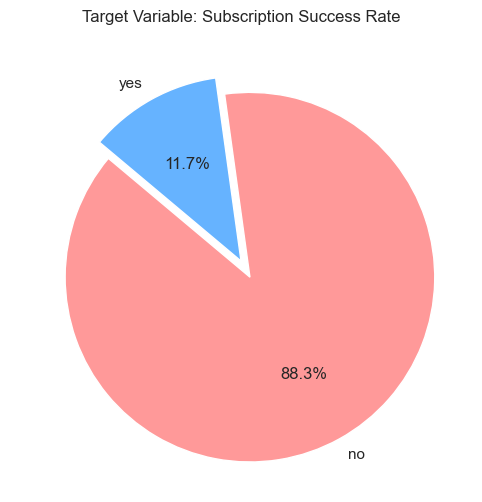

In [69]:
# Class Imbalance (Pie Chart)
plot_target_distribution(train_df)

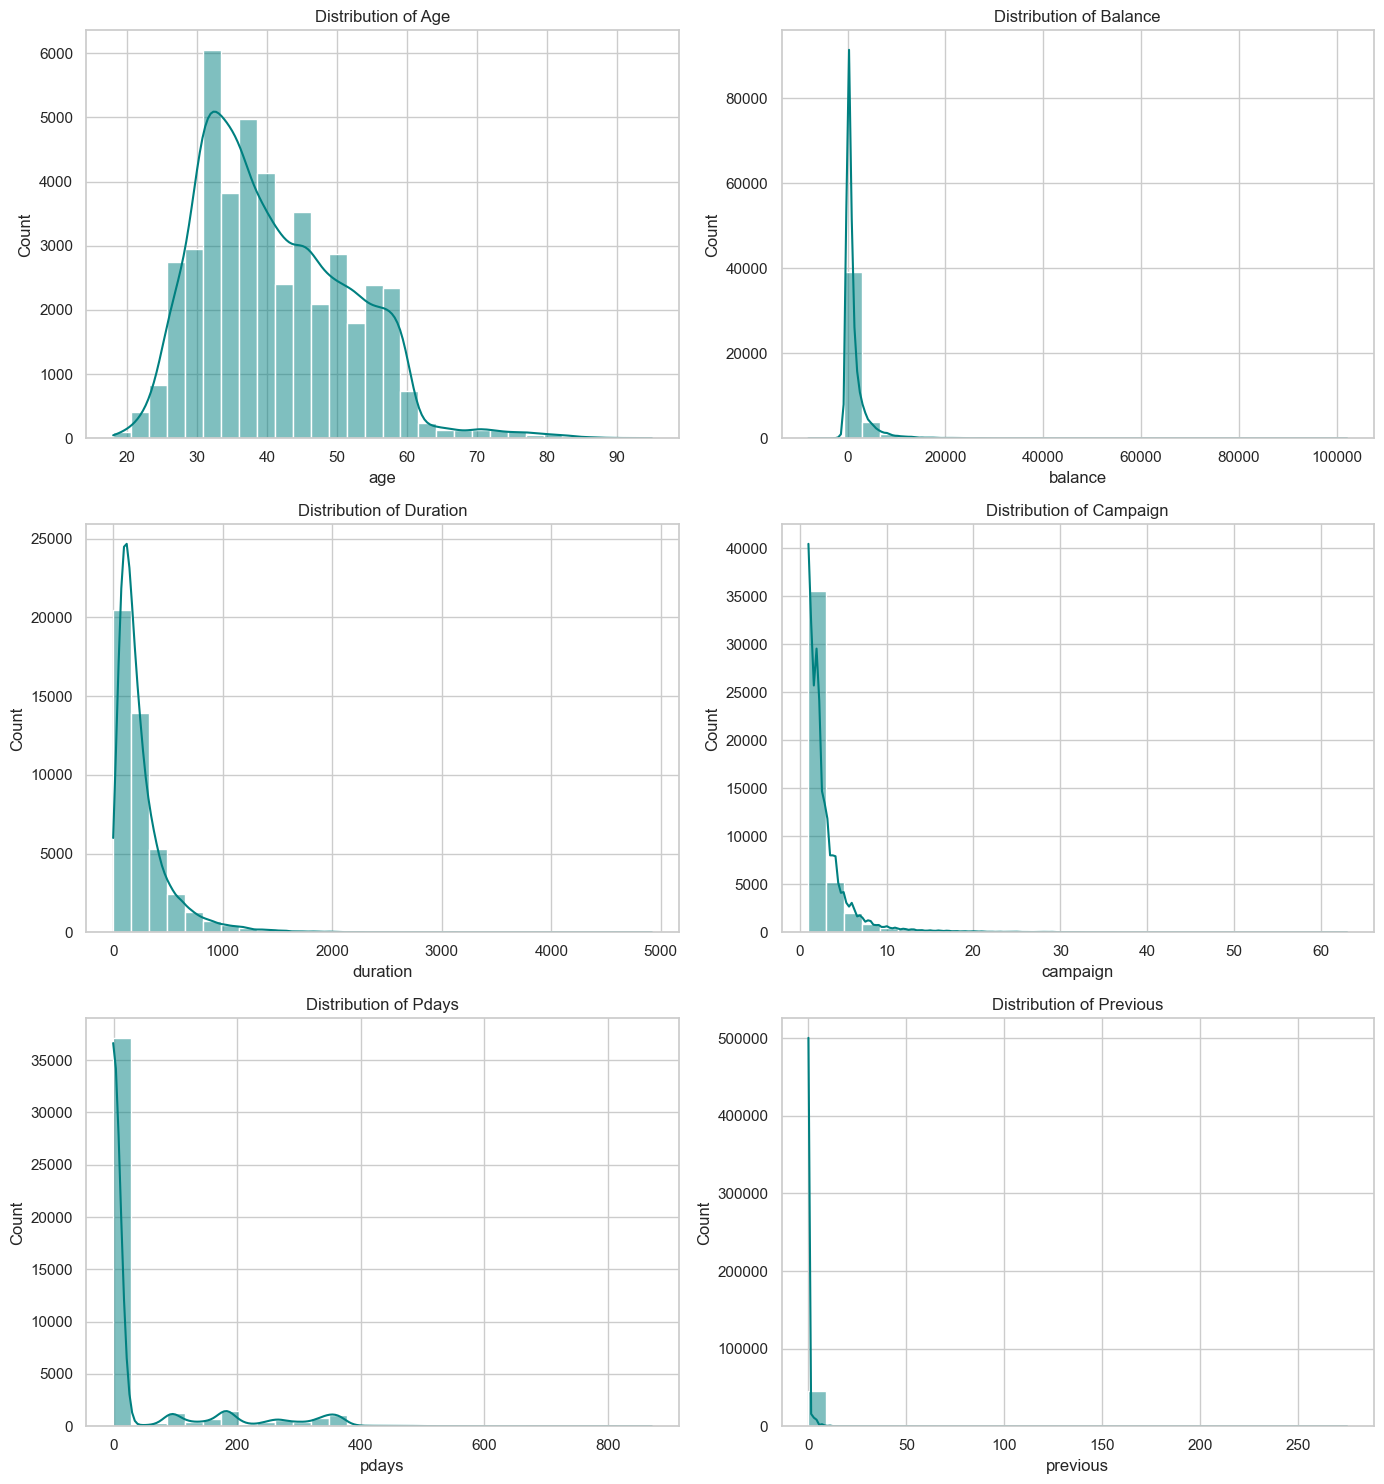

In [70]:
# Numeric Distributions 
plot_numeric_distributions(train_df)

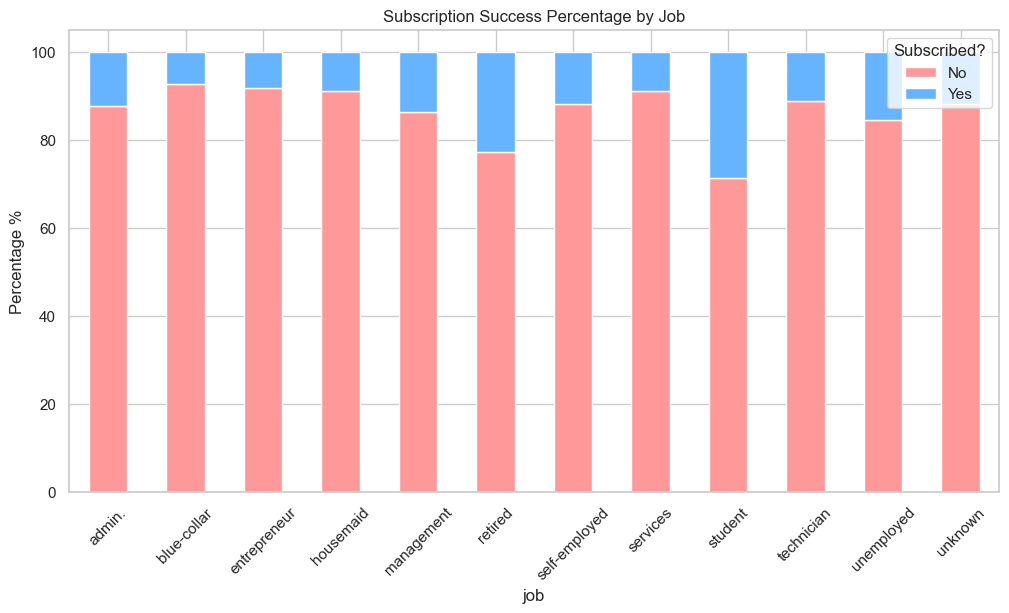

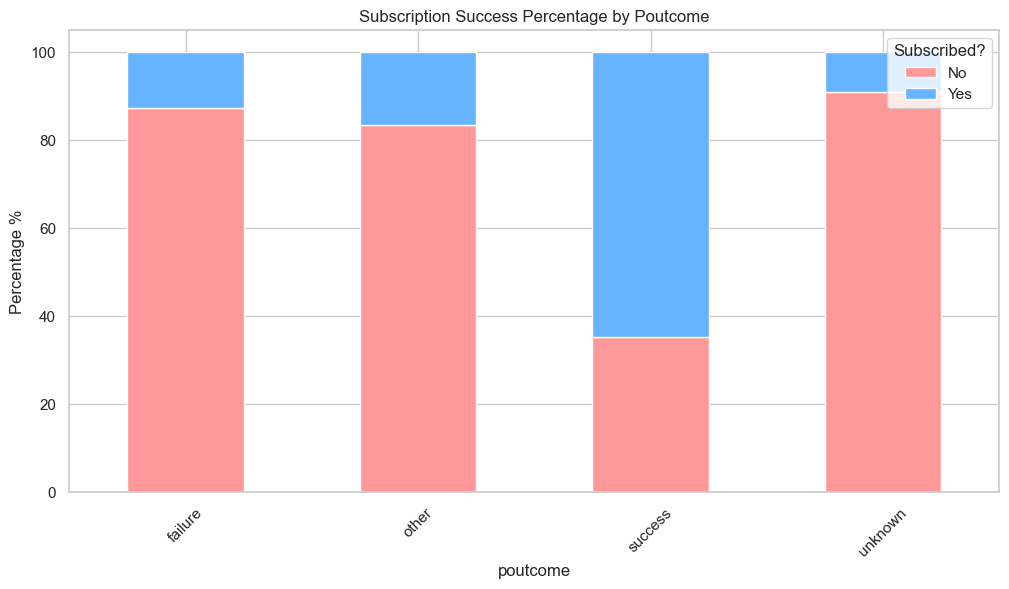

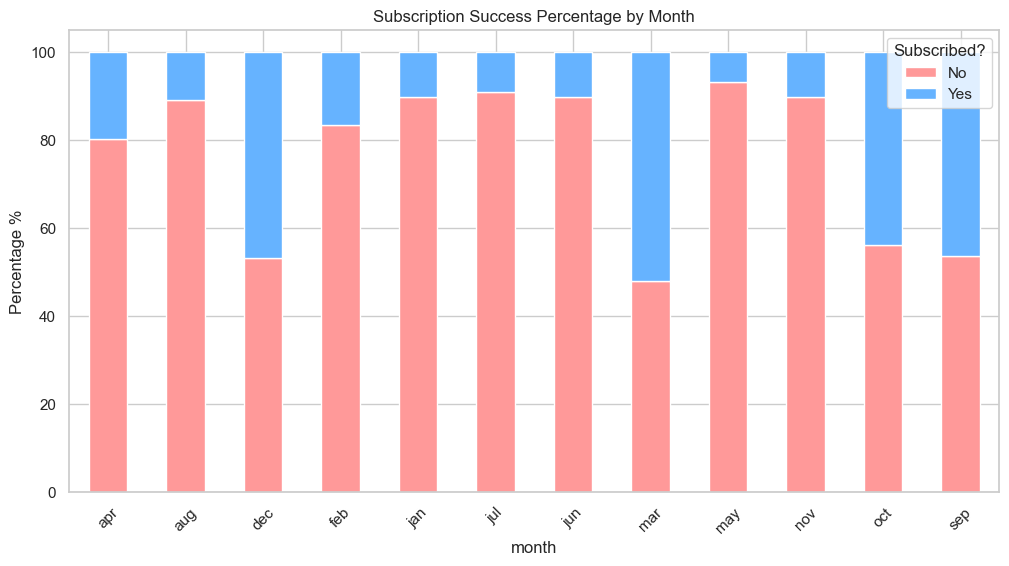

In [71]:
# 3. Categorical Analysis 
plot_categorical_proportions(train_df, 'job')
plot_categorical_proportions(train_df, 'poutcome') 
plot_categorical_proportions(train_df, 'month') 

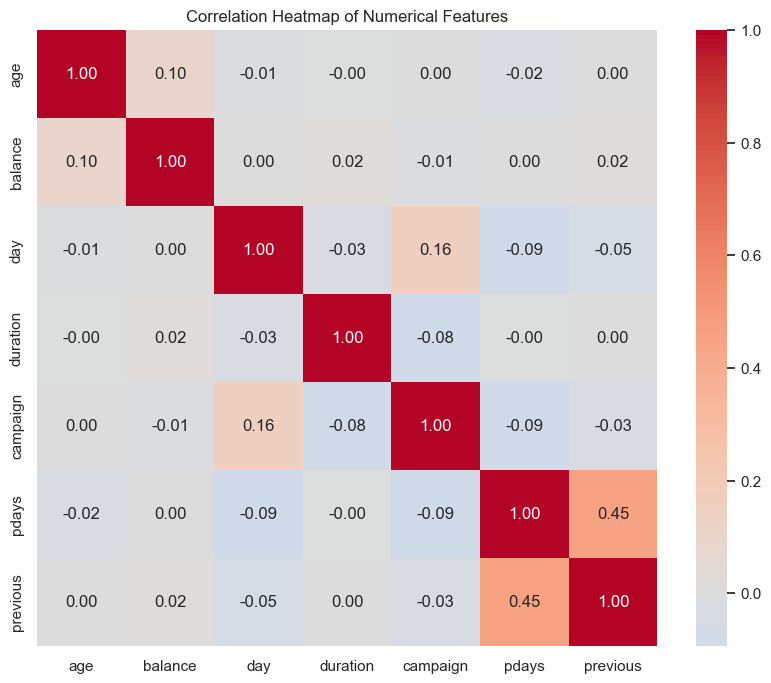

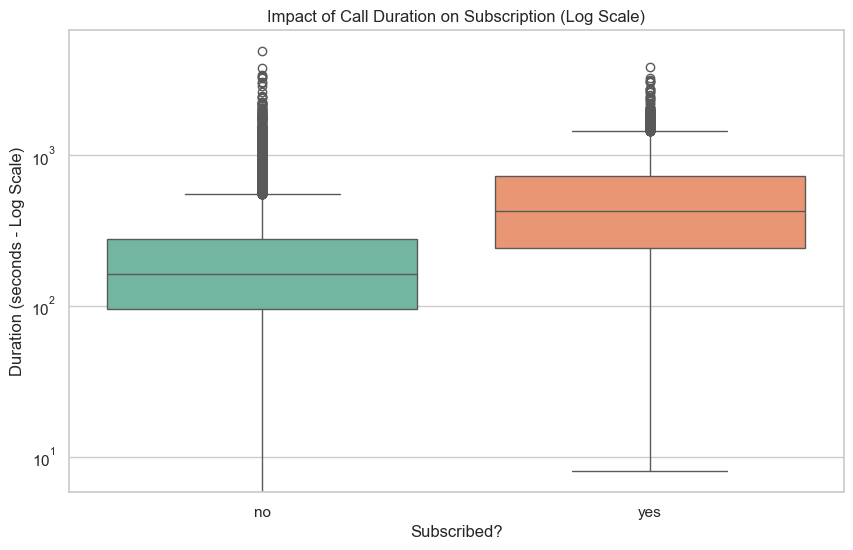

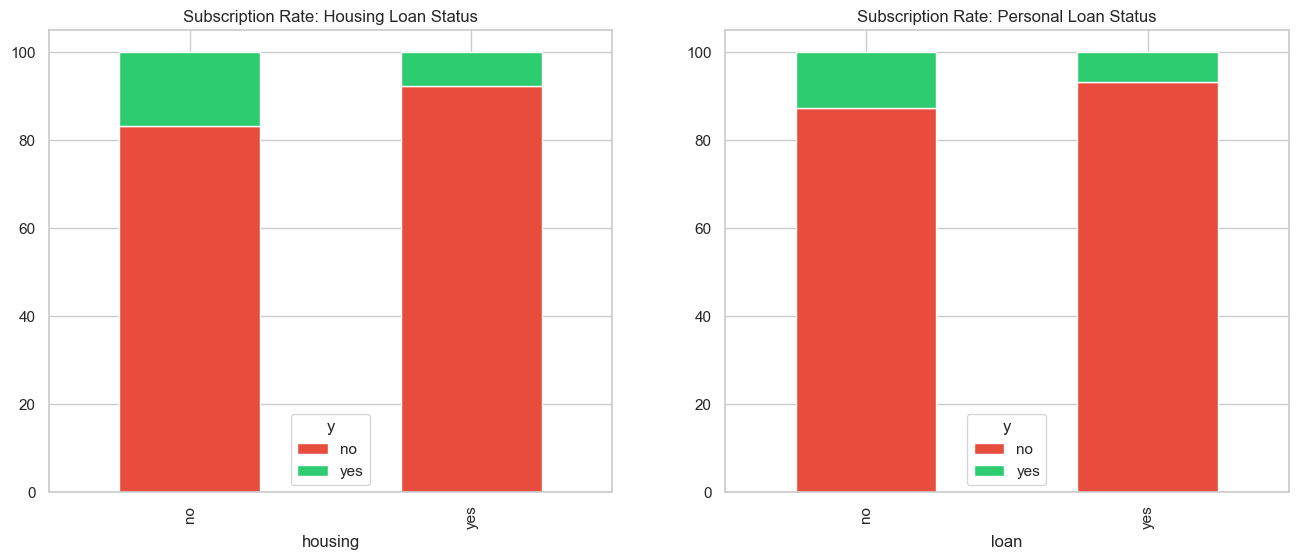

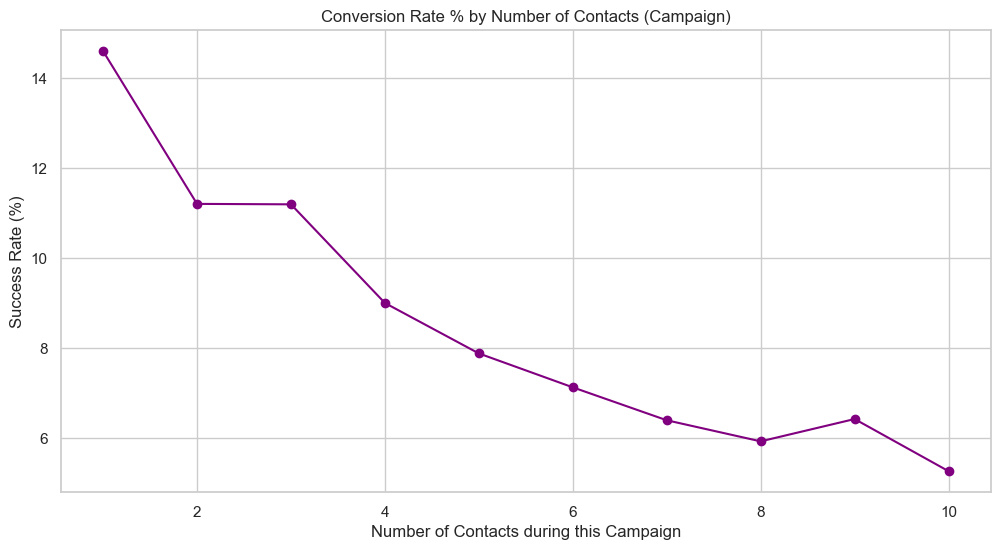

In [72]:
# 4. Advanced Insights 
plot_correlation_heatmap(train_df)
plot_duration_impact(train_df)
plot_debt_vs_conversion(train_df)
plot_campaign_efficiency(train_df)

### Preprocessing

In [73]:
# For both education and month, it matters how close they are, therefore ordinal encoding is appropriate. 
EDUCATION_ORDER = {
    'primary':   1,
    'secondary': 2,
    'tertiary':  3,
}
 
MONTH_ORDER = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4,
    'may': 5, 'jun': 6, 'jul': 7, 'aug': 8,
    'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12,
}

# Yes or no is binary, so we can map to 1/0. 
BINARY_COLS = ['default', 'housing', 'loan']
 
# Columns with no natural order → one-hot encoded
OHE_COLS = ['job', 'marital', 'contact', 'poutcome']
 
# Right-skewed numerics (based on visualization of their distributions) that benefit from log compression.
# balance can be negative so it is handled separately
LOG_COLS = ['duration', 'campaign', 'pdays', 'previous']

In [74]:
# Preprocessing structure through pipeline
from scipy.fftpack import shift


def preprocess_data(df):
    df = df.copy()


    # Missing Removal, in dataset, missing values are represented as 'unknown' strings. We will replace them with NaN and then impute.
    df.replace('unknown', np.nan, inplace=True)
 
    for col in df.columns:
        if df[col].isna().any():
            df[col].fillna(df[col].mode()[0], inplace=True)
 
    assert df.isna().sum().sum() == 0, "Unexpected NaNs remain after imputation"


    # Ourlier Removal
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != 'y']
    
    Q1 = df[numeric_cols].quantile(0.25)
    Q3 = df[numeric_cols].quantile(0.75)
    IQR = Q3 - Q1
    
    for col in numeric_cols:
        lower = Q1[col] - 1.5 * IQR[col]
        upper = Q3[col] + 1.5 * IQR[col]
        df[col] = np.clip(df[col], lower, upper)

    # Log transformation for skewed features
    for col in LOG_COLS:
            df[col] = np.log1p(df[col])
    
    shift = df['balance'].min()
    if shift < 0:
        df['balance'] = df['balance'] - shift
    df['balance'] = np.log1p(df['balance'])

    # Categorical Encoding
    if 'education' in df.columns:
        df['education'] = df['education'].map(EDUCATION_ORDER)
   
    # Months are cyclical, therefore they mapped to sin/cos so Dec and Jan are neighbours.
    # Two columns are needed: sin alone maps Jan and Jul to the same value.
    month_num = df['month'].map(MONTH_ORDER)
    df['month_sin'] = np.sin(2 * np.pi * month_num / 12)
    df['month_cos'] = np.cos(2 * np.pi * month_num / 12)
    df.drop(columns=['month'], inplace=True)

 
    for col in BINARY_COLS:
        df[col] = df[col].map({'yes': 1, 'no': 0})
 
    #   One-hot encode the remaining categorical features, ensuring we only encode those that are present in the dataset.
    df = pd.get_dummies(df, columns=OHE_COLS, drop_first=True, dtype=int)
 
    #   4e. Target
    df['y'] = df['y'].map({'yes': 1, 'no': 0})
 
    # FEATURE ENGINEERING: contact_ratio: how many prior contacts relative to this campaign
    df['contact_ratio'] = df['previous'] / (df['campaign'] + 1)
 
    return df




In [75]:
def split_and_scale(df, target='y', test_size=0.2, random_state=42):
    # Splits into train/test and applies StandardScaler to numeric features.
    # Scaler is fitted only on X_train to prevent data leakage.

    X = df.drop(columns=[target])
    y = df[target]
 
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
 
    # Scale only on training data, then apply to test
    scaler = preprocessing.StandardScaler()
    X_train = pd.DataFrame(
        scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
    )
    X_test = pd.DataFrame(
        scaler.transform(X_test), columns=X_test.columns, index=X_test.index
    )
 
    print(f"Train: {X_train.shape}, Test: {X_test.shape}")
    print(f"Class balance (train) — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}")
 
    return X_train, X_test, y_train, y_test


In [76]:
def complete_pipeline():
    train_df = load_data(test=False)

    # Preprocessing
    clean_df = preprocess_data(train_df)
    X_train, X_test, y_train, y_test = split_and_scale(clean_df)
    # Models Comparison
    # Evaluation